In [14]:
# Detektrohub Ausmessung
import numpy as np

A5, B5 = np.loadtxt("../Messdaten/20260615_MOKE/Detektorhub.dat", delimiter=",", unpack=True, usecols=(0,1)) # in 10^-5 V
A3, B3 = np.loadtxt("../Messdaten/20260615_MOKE/Detektorhub.dat", delimiter=",", unpack=True, usecols=(2,3)) # in 10^-3 V
A3 = A3[A3!=0]
B3 = B3[B3!=0]

for nom, array in zip(["A Darkframe", "B Darkframe", "A Flatfield", "B Flatfield"], [A5, B5, A3, B3]):
    print(nom, array.mean(), "Mittelwert von", len(array), "Messungen")

A Darkframe 528.6 Mittelwert von 10 Messungen
B Darkframe 535.1 Mittelwert von 10 Messungen
A Flatfield 7848.2 Mittelwert von 5 Messungen
B Flatfield 7839.8 Mittelwert von 5 Messungen


     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 1.122e+01  5.334e+00 ...  7.313e+00 -4.031e+00]
           x: [ 9.124e+02 -3.060e+03  1.230e+02 -3.242e+02]
        cost: 1188.3152108035601
         jac: [[-2.962e-01  6.224e-02 -1.454e+01 -1.000e+00]
               [-2.200e-01  8.551e-02 -1.319e+01 -1.000e+00]
               ...
               [-3.786e-01  3.709e-02 -1.545e+01 -1.000e+00]
               [-2.962e-01  6.224e-02 -1.454e+01 -1.000e+00]]
        grad: [-1.598e-04 -5.162e-05  8.030e-05  1.852e-05]
  optimality: 0.00015977975479164463
 active_mask: [0 0 0 0]
        nfev: 1371
        njev: None


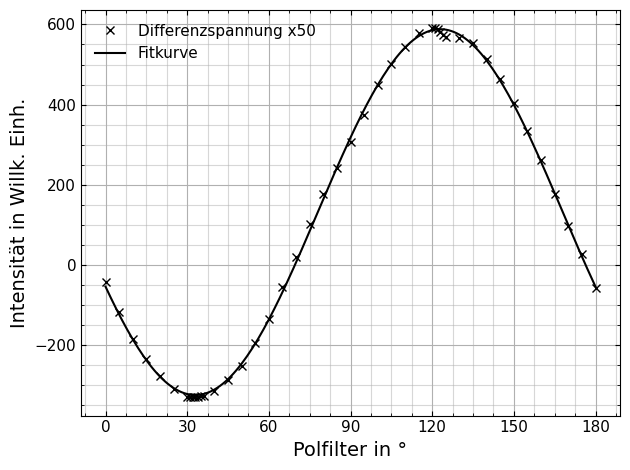

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares

def ND(slot):
    OD = {1:0, 2:0.5, 3:1, 4:2, 5:3, 6:4}
    return 10**(-OD[slot])

def I(B, I0, n, a, C):
    n, B, a = n*np.pi/180, B*np.pi/180, a*np.pi/180
    return I0/2*(1+np.cos(2*n)*np.cos(2*(B - a))) + C

def I_res(coeff, Imess, B):
    I0, n, a, C = coeff
    return Imess - I(B, I0, n, a, C)

mw1 = {0: 2.76/ND(3),
5: 2.04/ND(3),
10: 5.04/ND(2),
15: 3.50/ND(2),
20: 2.16/ND(2),
25: 1.32/ND(2),
30: 2.67/ND(1),
31: 2.31/ND(1),
32: 2.30/ND(1),
33: 2.22/ND(1),
34: 2.26/ND(1),
35: 2.30/ND(1),
36: 2.38/ND(1),
40: 3.36/ND(1),
45: 5.49/ND(1),
50: 2.70/ND(2),
55: 4.02/ND(2),
60: 5.68/ND(2),
65: 2.20/ND(3),
70: 2.77/ND(3),
75: 3.38/ND(3),
80: 4.05/ND(3),
85: 4.68/ND(3),
90: 5.24/ND(3),
95: 5.84/ND(3),
100: 6.36/ND(3),
105: 6.78/ND(3),
110: 0.70/ND(4),
115: 0.73/ND(4),
120: 0.74/ND(4),
122: 0.74/ND(4),
123: 0.74/ND(4),
124: 0.74/ND(4),
125: 0.74/ND(4),
126: 0.75/ND(4),
127: 0.76/ND(4),
128: 0.76/ND(4),
129: 0.76/ND(4),
130: 0.76/ND(4),
135: 0.73/ND(4),
140: 7.63/ND(3),
145: 7.22/ND(3),
150: 6.77/ND(3),
155: 6.09/ND(3),
160: 5.49/ND(3),
165: 4.88/ND(3),
170: 4.20/ND(3),
175: 3.52/ND(3),
180: 2.83/ND(3)}

mw2 = {0: 1.88/ND(2),
       5: 1.40/ND(2),
       10: 3.10/ND(1),
       15: 2.12/ND(1),
       20: 1.24/ND(1),
       25: 0.66/ND(1),
       30: 0.31/ND(1),
       31: 0.31/ND(1),
       32: 0.30/ND(1),
       33: 0.30/ND(1),
       34: 0.31/ND(1),
       35: 0.34/ND(1),
       36: 0.38/ND(1),
       40: 0.62/ND(1),
       45: 1.20/ND(1),
       50: 2.09/ND(1),
       55: 3.22/ND(1),
       60: 4.44/ND(1),
       65: 6.03/ND(1),
       70: 7.48/ND(1),
       75: 2.86/ND(2),
       80: 3.31/ND(2),
       85: 3.58/ND(2),
       90: 3.97/ND(2),
       95: 4.42/ND(2),
       100: 4.90/ND(2),
       105: 5.25/ND(2),
       110: 5.53/ND(2),
       115: 5.76/ND(2),
       120: 5.85/ND(2),
       121: 5.86/ND(2),
       122: 5.85/ND(2),
       123: 5.82/ND(2),
       124: 5.77/ND(2),
       125: 5.74/ND(2),
       130: 5.68/ND(2),
       135: 5.60/ND(2),
       140: 5.33/ND(2),
       145: 5.00/ND(2),
       150: 4.61/ND(2),
       155: 4.16/ND(2),
       160: 3.69/ND(2),
       165: 3.15/ND(2),
       170: 2.64/ND(2),
       175: 7.09/ND(1),
       180: 5.46/ND(1)}

ref2 = {0: 6.80, 
5: 6.79,
10: 6.79,
15: 6.79,
20: 6.79,
25: 6.84,
30: 6.88,
31: 6.89,
32: 6.88,
33: 6.89,
34: 6.89,
35: 6.89,
36: 6.90,
40: 6.90,
45: 6.91,
50: 7.14,
55: 7.13,
60: 7.13,
65: 7.11,
70: 7.09,
75: 7.01,
80: 6.94,
85: 6.48,
90: 6.40,
95: 6.47,
100: 6.53,
105: 6.58,
110: 6.63,
115: 6.65,
120: 6.70,
121: 6.73,
122: 6.75,
123: 6.76,
124: 6.77,
125: 6.76,
130: 6.65,
135: 6.62,
140: 6.58,
145: 6.53,
150: 6.49,
155: 6.45,
160: 6.42,
165: 6.41,
170: 6.40,
175: 6.52,
180: 6.62}

diff = np.array([(B-A)*50 for A, B in zip(list(ref2.values()), list(mw2.values()))])

x0 = [180, 1, 120, 200]
fit = least_squares(I_res, x0, args=(diff, np.array(list(mw2))), method="lm")
print(fit)
I0, n, a, C = fit.x

fig, ax = plt.subplots()

fitx = np.arange(181)


ax.plot(list(mw2), diff, "xk", label="Differenzspannung x50")
ax.plot(fitx, I(fitx, I0, n, a, C), "-k", label="Fitkurve")


xticks = np.arange(0, 181, step=30)
ax.set_xticks(xticks)

ax.set_xlabel("Polfilter in °", fontsize=14)
ax.set_ylabel("Intensität in Willk. Einh.", fontsize=14)

ax.tick_params(axis="both", which="both", labelsize=11, direction="in", top=True, right=True)

ax.minorticks_on()
ax.grid(which="major")
ax.grid(which="minor", alpha=0.5)
ax.legend(fontsize=11, frameon=False)
fig.tight_layout()